**Question1**

part1:

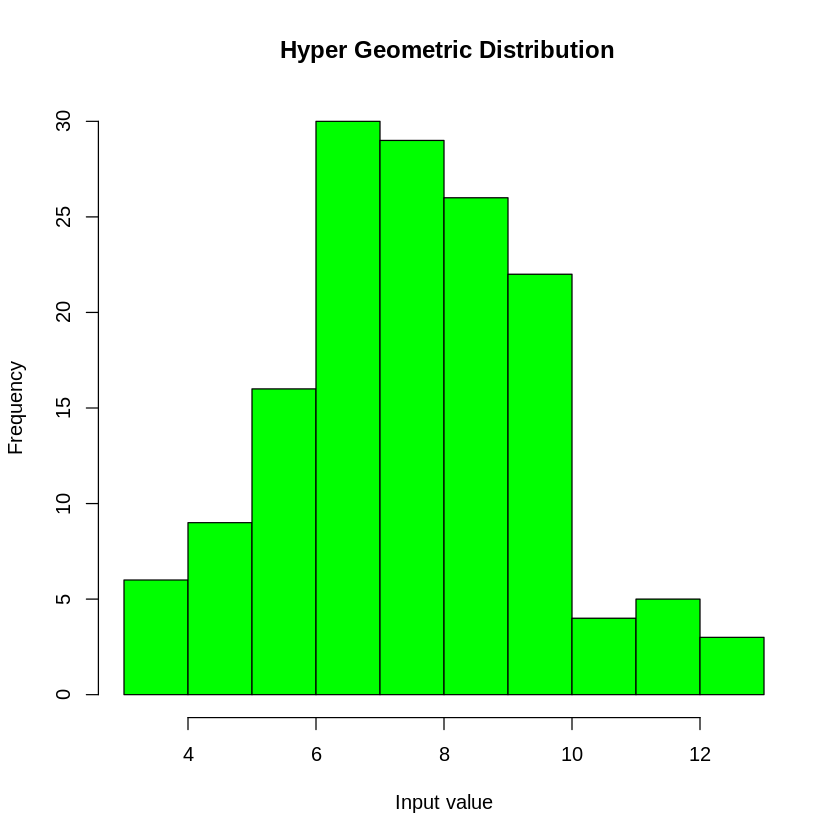

In [ ]:
set.seed(530)
N <- 100
n <- 150
k <- 20
m <- 40
y <- rhyper(n,k,N-k,m)
hist(y,main=" Hyper Geometric Distribution",xlab="Input value",col = "green")


part2:

In [ ]:
calculate_theory_mean <- function(){
  number_of_all <- 100
  cheating <- 20
  check_number <- 40
  theory_mean <- check_number * (cheating / number_of_all)
  theory_variance <- (check_number * (cheating / number_of_all) * ((number_of_all - cheating) / number_of_all) * ((number_of_all - cheating) / (number_of_all - 1)))
  return(list(mean = theory_mean, variance = theory_variance))
}
calculate_mean_and_variance <- function(){
  sample_number <- seq(100, 10000, by = 50)
  theory_value <- calculate_theory_mean()
  theory_mean <- theory_value$mean
  theory_variance <- theory_value$variance
  final_results <- data.frame(
    n = sample_number,
    simulated_mean = numeric(length(n_values)),
    simulated_variance = numeric(length(n_values)),
    theoretical_mean = theory_mean,
    theoretical_variance = theory_variance
  )

   for (i in 1:length(sample_number)) {
    n <- sample_number[i]
    simulated_data <- rhyper(n,k,N-k,m)
    simulated_mean <- mean(simulated_data)
    simulated_variance <- var(simulated_data)
    results$simulated_mean[i] <- simulated_mean
    results$simulated_variance[i] <- simulated_variance
  }
  return(final_results)
}


part3:

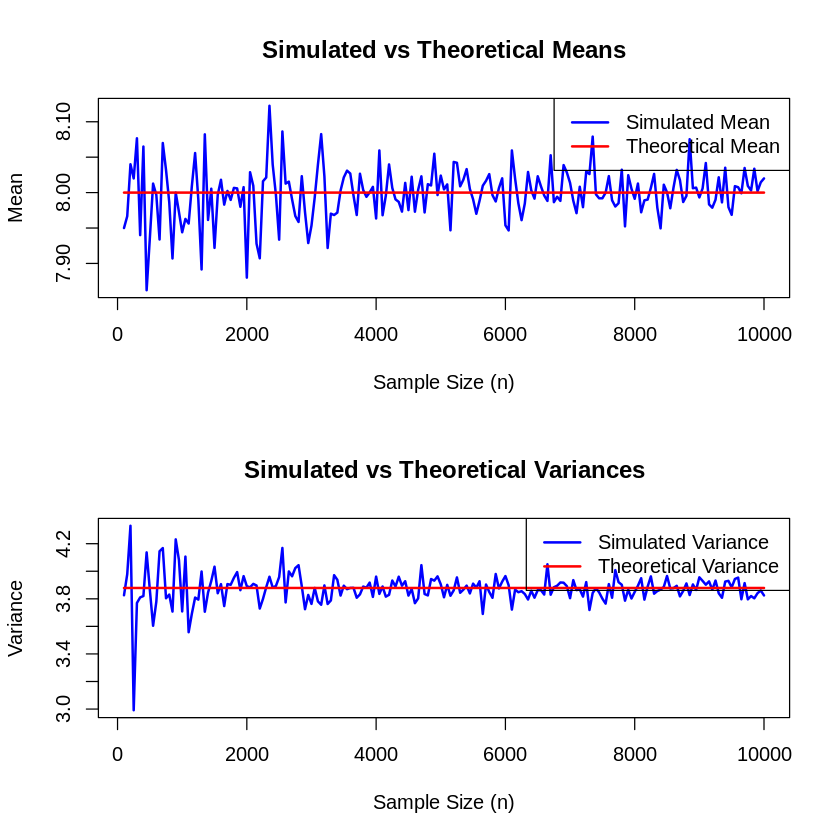

In [ ]:
calculate_theory_mean <- function() {
  number_of_all <- 100
  cheating <- 20
  check_number <- 40
  theory_mean <- check_number * (cheating / number_of_all)
  theory_variance <- check_number * (cheating / number_of_all) * ((number_of_all - cheating) / number_of_all) *
                     ((number_of_all - check_number) / (number_of_all - 1))
  return(list(mean = theory_mean, variance = theory_variance))
}
calculate_mean_and_variance <- function() {
  sample_number <- seq(100, 10000, by = 50)
  theory_value <- calculate_theory_mean()
  theory_mean <- theory_value$mean
  theory_variance <- theory_value$variance
  k <- 20
  N <- 100
  m <- 40
  final_results <- data.frame(
    n = sample_number,
    simulated_mean = numeric(length(sample_number)),
    simulated_variance = numeric(length(sample_number)),
    theoretical_mean = rep(theory_mean, length(sample_number)),
    theoretical_variance = rep(theory_variance, length(sample_number))
  )
  for (i in seq_along(sample_number)) {
    n <- sample_number[i]
    simulated_data <- rhyper(n, k, N - k, m)
    final_results$simulated_mean[i] <- mean(simulated_data)
    final_results$simulated_variance[i] <- var(simulated_data)
  }
  return(final_results)
}
results <- calculate_mean_and_variance()
par(mfrow = c(2, 1))
plot(results$n, results$simulated_mean, type = "l", col = "blue", lwd = 2,
     xlab = "Sample Size (n)", ylab = "Mean",
     main = "Simulated vs Theoretical Means")
lines(results$n, results$theoretical_mean, col = "red", lwd = 2)
legend("topright", legend = c("Simulated Mean", "Theoretical Mean"),
       col = c("blue", "red"), lty = 1, lwd = 2)
plot(results$n, results$simulated_variance, type = "l", col = "blue", lwd = 2,
     xlab = "Sample Size (n)", ylab = "Variance",
     main = "Simulated vs Theoretical Variances")
lines(results$n, results$theoretical_variance, col = "red", lwd = 2)
legend("topright", legend = c("Simulated Variance", "Theoretical Variance"),
       col = c("blue", "red"), lty = 1, lwd = 2)
par(mfrow = c(1, 1))
hist_data <- results$histograms


همانطور که مشاهده میشود با افزایش نمونه دوو جواب عملی و تئوری نزدیک میشوند:

part4:

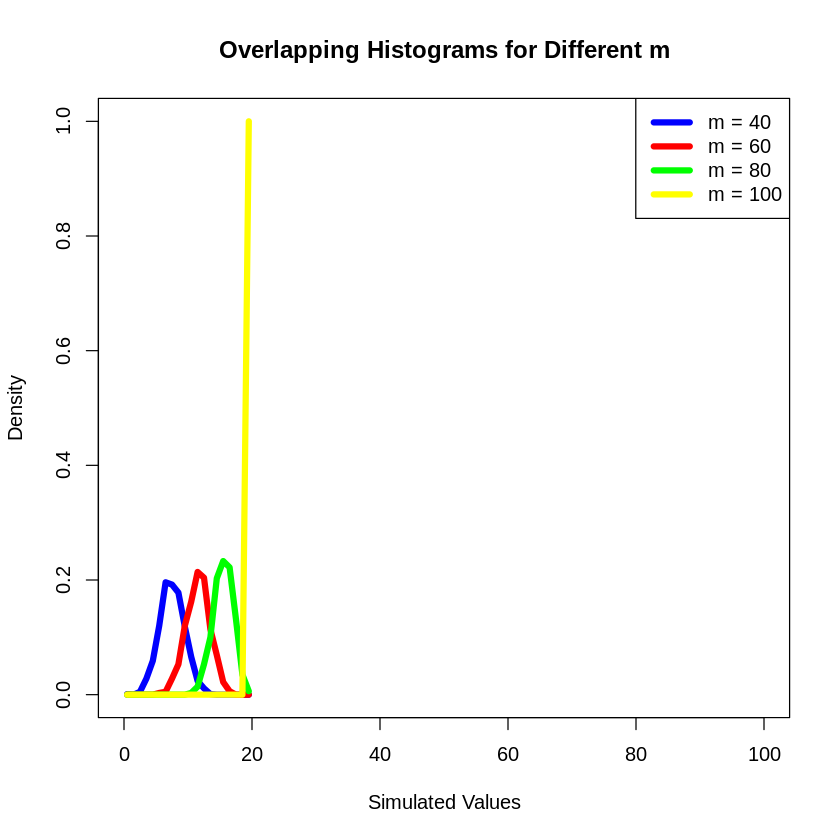

In [ ]:
m <- c(40, 60, 80, 100)
N <- 100
k <- 20
n <- 1000
results <- list()
colors <- c("blue", "red", "green", "yellow")
for (i in seq_along(m)) {
  results[[i]] <- rhyper(n, k, N - k, m[i])
}
hist_data <- lapply(results, function(x) hist(x, breaks = seq(0, 20, by = 1), plot = FALSE))
plot(hist_data[[1]]$mids, hist_data[[1]]$density, type = "l", col = colors[1], lwd = 5,
     xlab = "Simulated Values", ylab = "Density", main = "Overlapping Histograms for Different m",
     ylim = c(0, max(sapply(hist_data, function(x) max(x$density))))
     ,xlim =c(0,100))

for (i in 2:length(m)) {
  lines(hist_data[[i]]$mids, hist_data[[i]]$density, col = colors[i], lwd = 5)
}
legend("topright", legend = paste("m =", m), col = colors, lty = 1, lwd = 5)


تعداد حوزه بیشتر احتمال تقلب بالاتر زیرا توزیع بیشتر خواهد شد

part5:

In [ ]:
Bin_pmf <- function(n,p,random_variable){
      results <- numeric(length(random_variable))
      for (i in seq_along(random_variable)){
        k <- random_variable[i]
        q <- (1-p) ^(n-k)
        choose_from <- choose(n,k)
        PMF <- choose_from*(p^k)*q
        results[i] <- PMF
      }
  return(results)
}
Hy_Geo_pmf <- function(N,p,n,random_variable){
  results <- numeric(length(random_variable))
  choose_from_sum_N <- choose(N,n)
  for(i in seq_along(random_variable)){
    k <- random_variable[i]
    P <- choose(p,k)
    Q <- choose(N-p,n-k)
    PMF <- (P*Q)/choose_from_sum_N
    results[i] <- PMF
  }
  return(results)
}

part6:

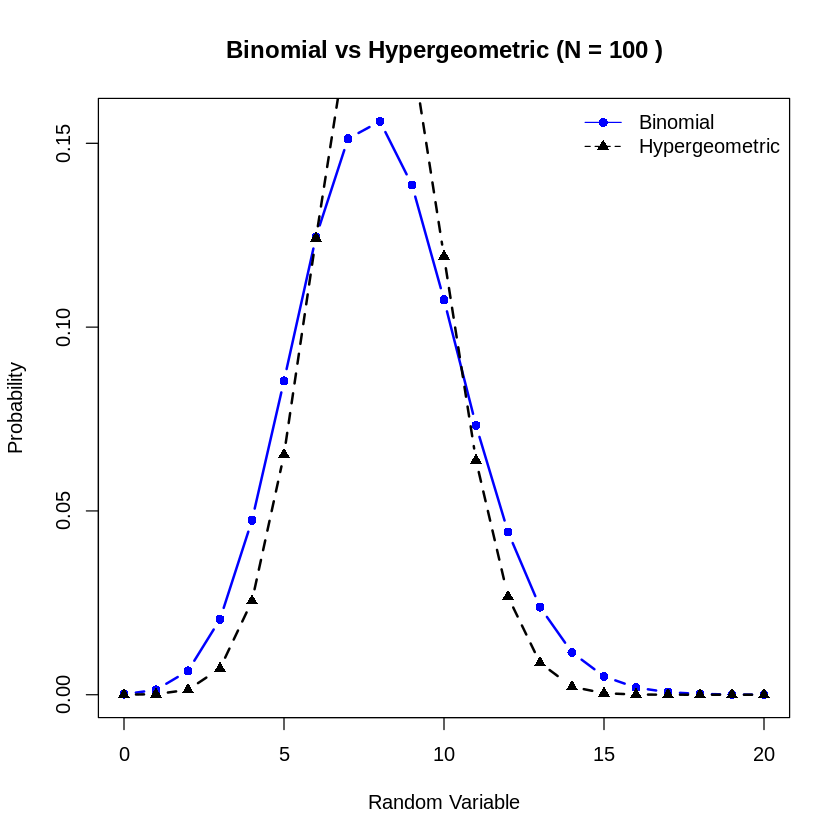

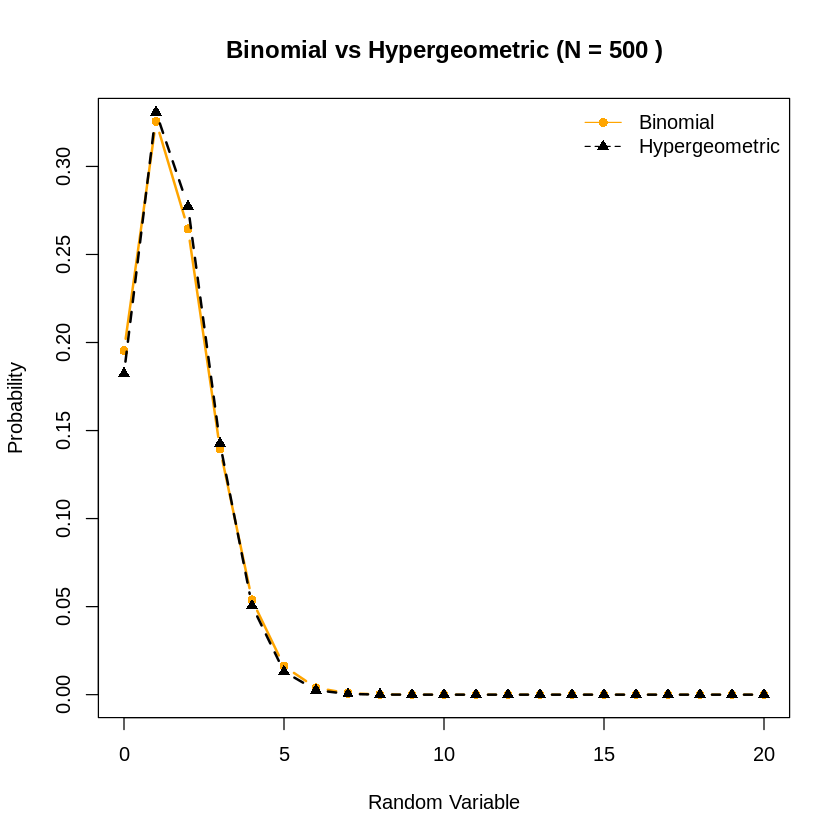

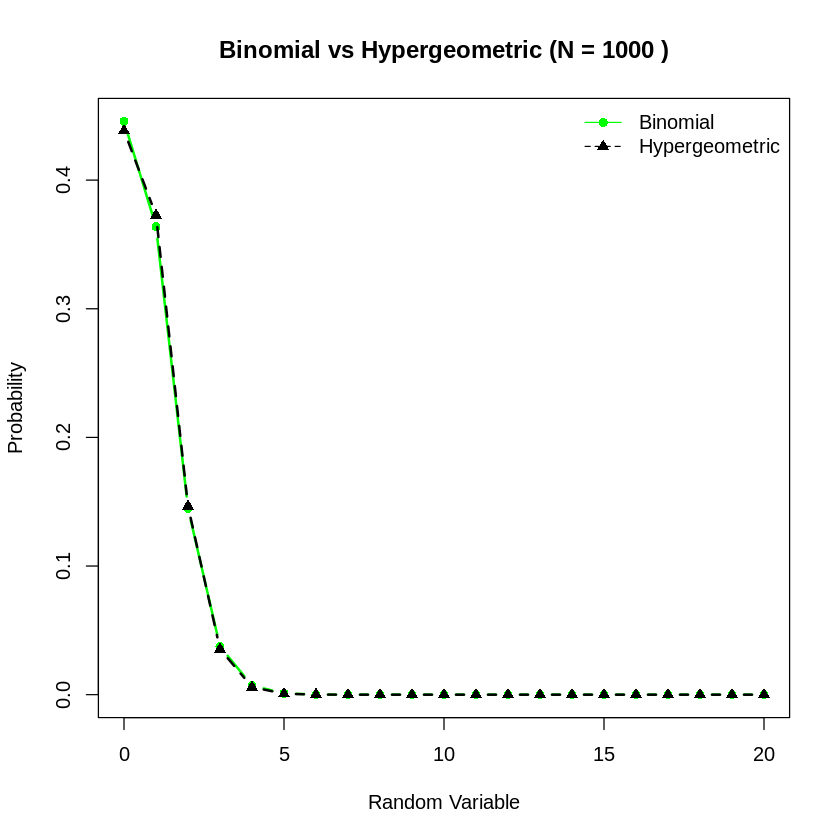

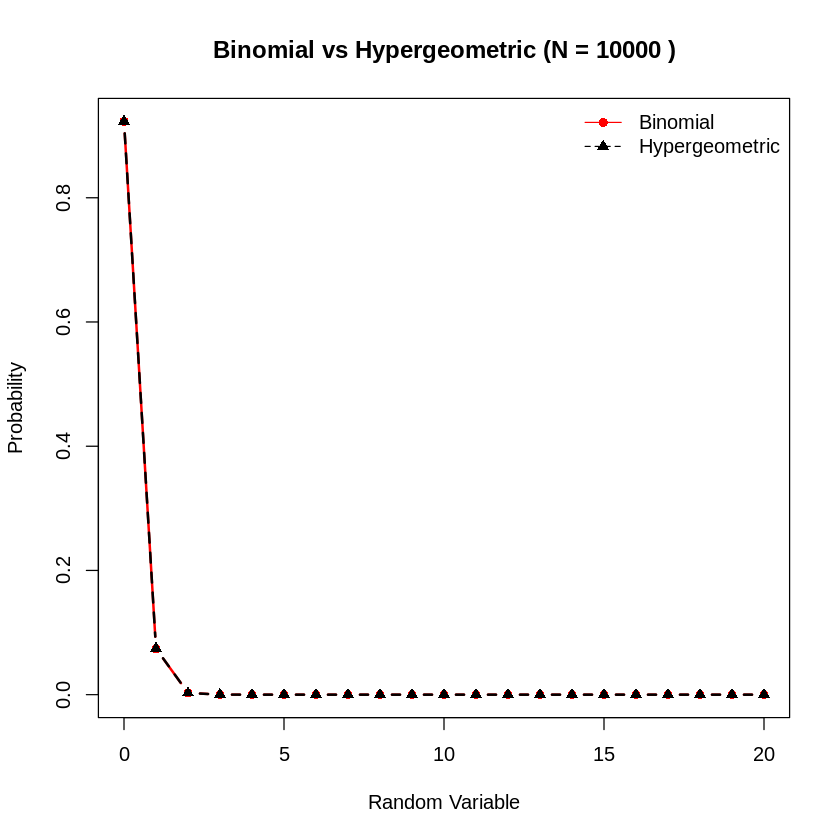

In [ ]:
plot_function <- function() {
  random_variable <- seq(0, 20)
  N <- c(100, 500, 1000, 10000)
  colors <- c("blue", "orange", "green", "red")
  for (i in seq_along(N)) {
    n <- N[i]
    Bin <- Bin_pmf(40, 20 / n, random_variable)
    HyGeo <- Hy_Geo_pmf(n, 20, 40, random_variable)
    plot(random_variable, Bin, type = "b", pch = 16, col = colors[i], lwd = 2,
         main = paste("Binomial vs Hypergeometric (N =", n, ")"),
         xlab = "Random Variable", ylab = "Probability")
    lines(random_variable, HyGeo, type = "b", pch = 17, col = "black", lty = 2, lwd = 2)
    legend("topright", legend = c("Binomial", "Hypergeometric"),
           col = c(colors[i], "black"), lty = c(1, 2), pch = c(16, 17), bty = "n")
  }
}
plot_function()


part7:

در واقع با افزایش جمعیت یعنی مثلا میل کردن به سمت بینهایت، نمودار دو توضیع به هم منطبق میشوند و در واقع انگار که میتوان توزیع هارا تقریب زد